# Loan Default Data Preprocessing
In this notebook, we are cleaning the loan default dataset for machine learning. We will follow standard steps like removing useless columns, checking for missing values, handling outliers, encoding text, and scaling numbers.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = pd.read_csv('Loan_default.csv')

## 1. Understand the Data & Clean Columns
First, let's look at the dataset and clean the column names so they are all lowercase. We will also drop the `loanid` column because IDs are not useful for prediction.

In [7]:
# Make column names lowercase to make typing easier
df.columns = df.columns.str.lower()

# Drop the loanid column
df.drop('loanid', axis=1, inplace=True)

# Look at the first 5 rows
display(df.head())

# Check data types
df.info()

,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,education,employmenttype,maritalstatus,hasmortgage,hasdependents,loanpurpose,hascosigner,default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   age             255347 non-null  int64  
 1   income          255347 non-null  int64  
 2   loanamount      255347 non-null  int64  
 3   creditscore     255347 non-null  int64  
 4   monthsemployed  255347 non-null  int64  
 5   numcreditlines  255347 non-null  int64  
 6   interestrate    255347 non-null  float64
 7   loanterm        255347 non-null  int64  
 8   dtiratio        255347 non-null  float64
 9   education       255347 non-null  object 
 10  employmenttype  255347 non-null  object 
 11  maritalstatus   255347 non-null  object 
 12  hasmortgage     255347 non-null  object 
 13  hasdependents   255347 non-null  object 
 14  loanpurpose     255347 non-null  object 
 15  hascosigner     255347 non-null  object 
 16  default         255347 non-null  int64  
dtypes: float64

## 2. Duplicates and Missing Values
We need to check if there are any duplicate rows or empty cells (NaN).

In [8]:
# Check for duplicates and remove them if any
print("Duplicates found:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

Duplicates found: 0

Missing values in each column:
age               0
income            0
loanamount        0
creditscore       0
monthsemployed    0
numcreditlines    0
interestrate      0
loanterm          0
dtiratio          0
education         0
employmenttype    0
maritalstatus     0
hasmortgage       0
hasdependents     0
loanpurpose       0
hascosigner       0
default           0
dtype: int64


## 3. Handle Outliers
Some people might have extremely high incomes that could confuse the model. We will use the IQR method to remove crazy outliers from the `income` column.

In [9]:
# IQR method for the 'income' column
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataset to keep only normal income ranges
df = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)]

print("Data shape after removing income outliers:", df.shape)

Data shape after removing income outliers: (255347, 17)


## 4. Encode Categorical Data
Machine learning models cannot read text. We have several text columns like education, employmenttype, and maritalstatus. We will convert them to numbers using LabelEncoder.

In [10]:
# Create the encoder
le = LabelEncoder()

# List of all text columns in our dataset
text_cols = ['education', 'employmenttype', 'maritalstatus', 
             'hasmortgage', 'hasdependents', 'loanpurpose', 'hascosigner']

# Loop through each text column and convert it to numbers
for col in text_cols:
    df[col] = le.fit_transform(df[col])

print("Data after encoding text to numbers:")
display(df.head())

Data after encoding text to numbers:


,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,education,employmenttype,maritalstatus,hasmortgage,hasdependents,loanpurpose,hascosigner,default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


## 5. Scale Numeric Columns
Columns like `income` are in the tens of thousands, while `age` is in the tens. We need to scale them down to a similar range (0 to 1) so the model treats them equally.

In [11]:
# Create the scaler
scaler = MinMaxScaler()

# List of numeric columns to scale
num_cols = ['age', 'income', 'loanamount', 'creditscore']

# Apply scaling
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Data after scaling:")
display(df[['age', 'income', 'loanamount', 'creditscore']].head())

Data after scaling:


,age,income,loanamount,creditscore
0,0.745098,0.525885,0.186070,0.400729
1,1.000000,0.262461,0.487512,0.287796
2,0.549020,0.512656,0.506892,0.275046
3,0.274510,0.123801,0.162446,0.806922
4,0.823529,0.040274,0.016894,0.606557


## 6. Visualization
Finally, let's plot a few graphs to understand the cleaned data better.

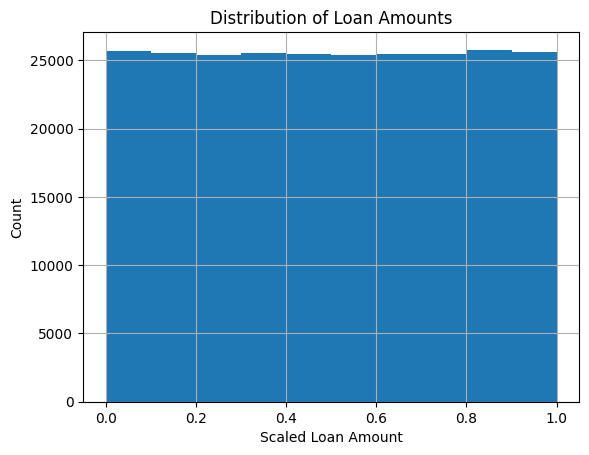

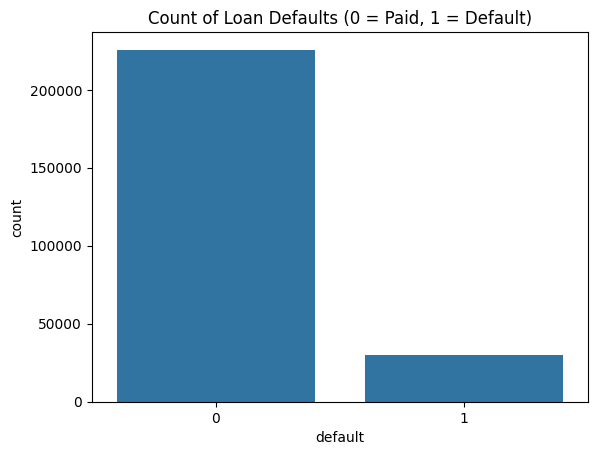

In [12]:
# Histogram to see the distribution of loan amounts
df['loanamount'].hist()
plt.title('Distribution of Loan Amounts')
plt.xlabel('Scaled Loan Amount')
plt.ylabel('Count')
plt.show()

# Count plot to see how many people defaulted vs paid
sns.countplot(x='default', data=df)
plt.title('Count of Loan Defaults (0 = Paid, 1 = Default)')
plt.show()

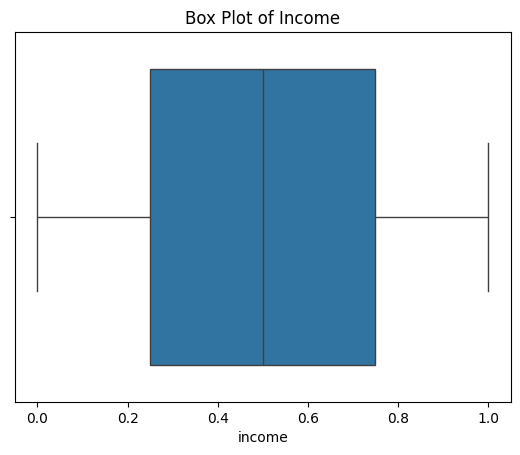

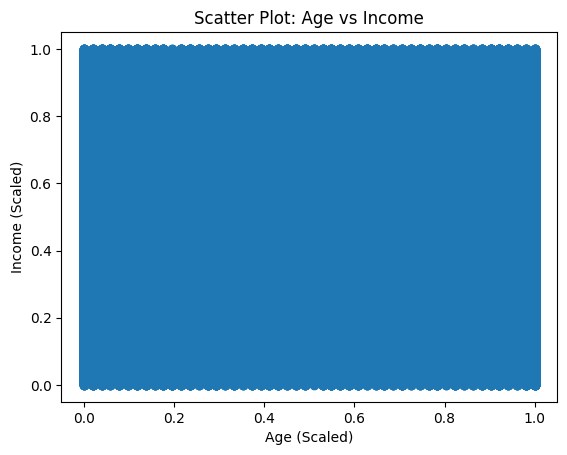

In [13]:
# Box Plot to spot outliers in the income column
sns.boxplot(x=df['income'])
plt.title('Box Plot of Income')
plt.show()

# Scatter Plot to see the relationship between Age and Income
plt.scatter(df['age'], df['income'])
plt.title('Scatter Plot: Age vs Income')
plt.xlabel('Age (Scaled)')
plt.ylabel('Income (Scaled)')
plt.show()

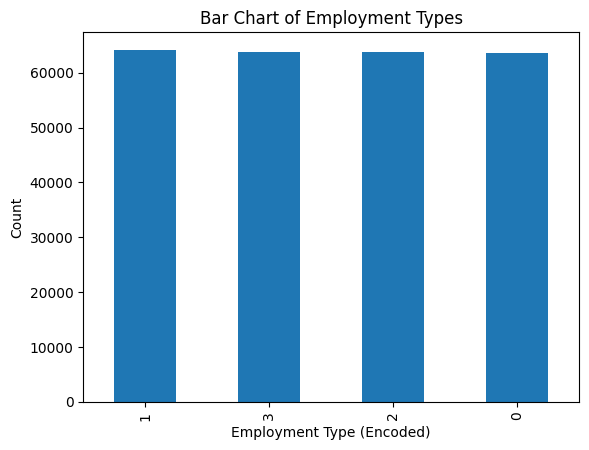

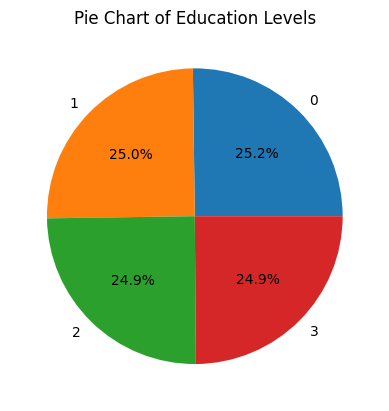

In [14]:
# Bar Chart for Employment Type
df['employmenttype'].value_counts().plot(kind='bar')
plt.title('Bar Chart of Employment Types')
plt.xlabel('Employment Type (Encoded)')
plt.ylabel('Count')
plt.show()

# Pie Chart for Education Level
df['education'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Pie Chart of Education Levels')
plt.ylabel('') # Hides the y-axis label to make the pie chart cleaner
plt.show()